# Eje 2b — Paridad put-call, intrínseco y moneyness

Derivados Financieros — QUANt UCEMA

Relaciones que no dependen del modelo de volatilidad (arbitraje) y el desglose del premio.

**Plan del notebook:**
1. Valor intrínseco, temporal y moneyness (repaso)
2. Paridad put-call (europeas con dividendos)
3. Verificar paridad con Black-Scholes
4. Sintéticos: fabricar call/put/forward
5. Idea de arbitraje (números toy)
6. Resumen


## 1) Valor intrínseco, temporal y moneyness

| Concepto | Call | Put |
|----------|------|-----|
| Intrínseco | $\max(S-K,0)$ | $\max(K-S,0)$ |
| Temporal | Prima − Intrínseco | Prima − Intrínseco |
| ITM | $S>K$ | $S<K$ |
| ATM | $S\approx K$ | $S\approx K$ |
| OTM | $S<K$ | $S>K$ |

*(Repaso de Eje 1c; acá lo conectamos con el precio de modelo.)*


In [1]:
import sys
sys.path.append('../../..')

import numpy as np
import matplotlib.pyplot as plt
from Codigo.pricing import opcion_europea_bs as bs

S, K, T, r, sigma, q = 100.0, 100.0, 0.5, 0.05, 0.25, 0.02
premium_c = bs('C', S, K, T, r, sigma, q)
premium_p = bs('P', S, K, T, r, sigma, q)
intr_c = max(S - K, 0)
intr_p = max(K - S, 0)

print(f'Call: prima={premium_c:.4f} | intrínseco={intr_c:.4f} | temporal={premium_c-intr_c:.4f}')
print(f'Put:  prima={premium_p:.4f} | intrínseco={intr_p:.4f} | temporal={premium_p-intr_p:.4f}')
print(f'Moneyness S/K = {S/K:.3f}')


Call: prima=7.6830 | intrínseco=0.0000 | temporal=7.6830
Put:  prima=6.2090 | intrínseco=0.0000 | temporal=6.2090
Moneyness S/K = 1.000


## 2) Paridad put-call (europeas)

Con tasa continua $r$ y dividend yield $q$:

$$
C - P = S e^{-qT} - K e^{-rT}
$$

Equivalente: **Call + cash $Ke^{-rT}$ = Put + subyacente descontado $Se^{-qT}$**.

Si se rompe la igualdad (después de costos), hay arbitraje.


## 3) Verificar paridad con Black-Scholes

BS **respeta** la paridad por construcción. Sirve como chequeo numérico.


In [2]:
def parity_rhs(S, K, T, r, q):
    return S * np.exp(-q * T) - K * np.exp(-r * T)

lhs = premium_c - premium_p
rhs = parity_rhs(S, K, T, r, q)
print(f'C - P = {lhs:.6f}')
print(f'Se^(-qT) - Ke^(-rT) = {rhs:.6f}')
print(f'|error| = {abs(lhs - rhs):.2e}')


C - P = 1.473992
Se^(-qT) - Ke^(-rT) = 1.473992
|error| = 0.00e+00


## 4) Sintéticos

A partir de la paridad:
- **Call sintético** $= P + S e^{-qT} - K e^{-rT}$
- **Put sintético** $= C - S e^{-qT} + K e^{-rT}$
- **Forward sintético** $= C - P$ (mismo payoff que long forward al strike $K$)


Call mercado (BS): 7.6830
Call sintético:    7.6830


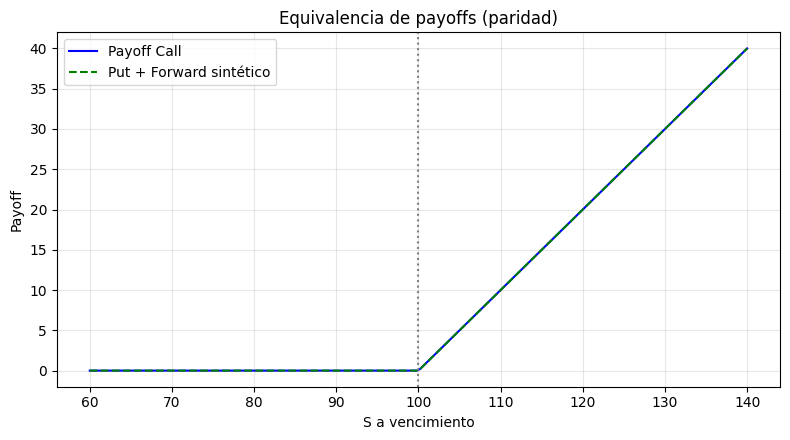

In [3]:
# Call sintético desde put + forward
c_synth = premium_p + parity_rhs(S, K, T, r, q)
print(f'Call mercado (BS): {premium_c:.4f}')
print(f'Call sintético:    {c_synth:.4f}')

# Payoff: long call vs long put + long forward sintético
from Codigo.analytics.payoffs import payoff_call, payoff_put, payoff_forwardSintetico

S_grid = np.linspace(60, 140, 200)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(S_grid, payoff_call(S_grid, K), 'b-', label='Payoff Call')
ax.plot(S_grid, payoff_put(S_grid, K) + payoff_forwardSintetico(S_grid, K),
        'g--', label='Put + Forward sintético')
ax.axvline(K, color='gray', ls=':')
ax.set_xlabel('S a vencimiento'); ax.set_ylabel('Payoff')
ax.set_title('Equivalencia de payoffs (paridad)')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 5) Idea de arbitraje (números toy)

Supongamos que en mercado cotizan $C^{\mathrm{mkt}}$ y $P^{\mathrm{mkt}}$ que **no** cumplen paridad.

Si $C - P > Se^{-qT} - Ke^{-rT}$: vender call, comprar put, comprar “forward” (o la canasta de paridad).
Si $C - P <$ RHS: la operatoria inversa.

En clase: no hace falta el detalle operativo; la idea es **misma exposición, distinto precio $\Rightarrow$ cash hoy sin riesgo**.


In [4]:
# Toy: put "caro" respecto del call
C_mkt, P_mkt = 10.0, 12.0  # inventados
gap = (C_mkt - P_mkt) - parity_rhs(S, K, T, r, q)
print(f'Gap (C-P) - RHS = {gap:.4f}')
if gap > 0:
    print('Señal: C-P demasiado alto → vender call, comprar put (+ hedge forward)')
elif gap < 0:
    print('Señal: C-P demasiado bajo → comprar call, vender put (+ hedge)')
else:
    print('Paridad ok')


Gap (C-P) - RHS = -3.4740
Señal: C-P demasiado bajo → comprar call, vender put (+ hedge)


## Resumen

- Prima = intrínseco + temporal; moneyness clasifica ITM/ATM/OTM.
- Paridad europeas: $C-P=Se^{-qT}-Ke^{-rT}$ (independiente de $\sigma$).
- Sintéticos permiten replicar call, put o forward.
- Roturas de paridad = oportunidad de arbitraje (en la práctica: costos, early exercise americanas, microestructura).

**Siguiente:** Eje 3 — armar estrategias como *carteras* de calls/puts.
